# ZarrDataManager
Accesses image data from a fileset in the [OME-NGFF](https://ngff.openmicroscopy.org/) (Zarr) format.

Create a `ZarrDataManager` from a url:

In [1]:
import zarr.storage
from cyeye.zarr import ZarrDataManager

ZARR_PATH = "s3://osco-390179198112-ap-northeast-2-an/52794_1490_HIC_20260616_H460-NucR_DTX_DRC_20X.zarr/"
store = zarr.storage.FsspecStore.from_url(ZARR_PATH, read_only=True)

zdm = ZarrDataManager(store)
zdm

Read metadata

In [23]:
print(f"Plate: {zdm.name}")
print(f"Rows: {zdm.n_rows}")
print(f"Columns: {zdm.n_columns}")
print(f"Wells: {zdm.n_wells}")
print()
zdm.print_wells()
print()

print(f"Timepoints: {zdm.n_timepoints}")
print(f"Z-planes: {zdm.n_z_planes}")
print(f"Channels: {zdm.channel_names}")

Plate: HIC_20260616_H460-NucR_DTX DRC_20X
Rows: 5
Columns: 7
Wells: 33

  2 3 4 6 7 8 10 
B ■ ■ ■ ■ ■ ■ ■  
C ■ ■ ■ ■ ■ ■ ■  
D ■ ■ ■ ■ ■ ■ ■  
E ■ ■ ■ ■ ■ ■    
F ■ ■ ■ ■ ■ ■    

Timepoints: 147
Z-planes: 1
Channels: ['Phase', 'Red']


Retrieve data by well, field, time point, channel, and Z-plane

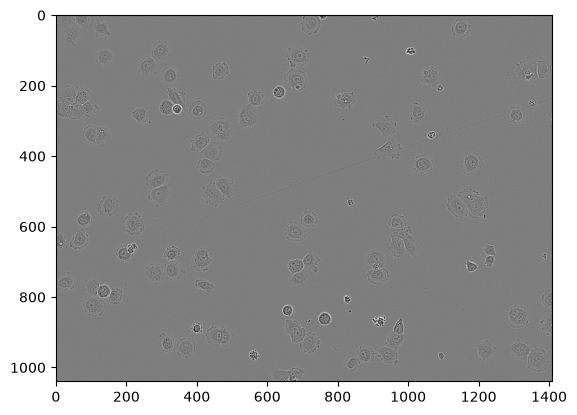

In [24]:
import matplotlib.pyplot as plt

image = zdm.select(well=("B", "2"), field=0, channel=0, time=0, z=0).load()
plt.imshow(image, cmap="grey")

Iterate through images in a selection

In [25]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# First 30 timepoints of the "Phase" channel, single well/field
selection = zdm.select(well=("B", "2"), field=0, channel=0, time=(0, 30))
images = list(selection.iter_images())

fig, ax = plt.subplots()
im = ax.imshow(images[0], cmap="gray")
ax.axis("off")
title = ax.set_title(
    f"Well B2, field 0, {zdm.channel_names[0]} channel — t=0"
)

def update(frame):
    im.set_data(images[frame])
    title.set_text(
        f"Well B2, field 0, {zdm.channel_names[0]} channel — t={frame}"
    )
    return [im, title]

anim = FuncAnimation(fig, update, frames=len(images), interval=150, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())